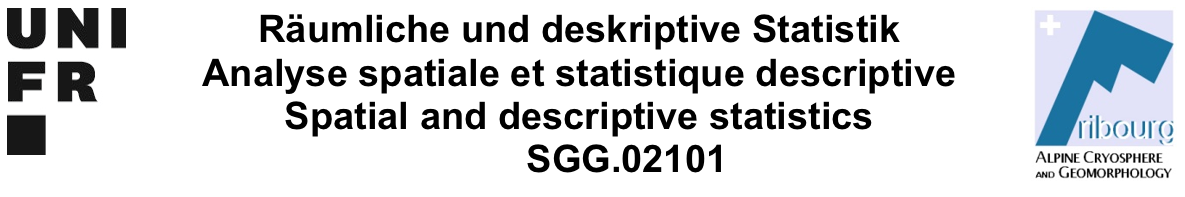


![boxplot_ndvi](https://drive.switch.ch/index.php/s/lSgNli7MGnh32us/download)
![dist_ndvi](https://drive.switch.ch/index.php/s/I4kWd9ZXYGYIPDR/download)

*Figure 1: Boxplots of NDVI samples (top) and their original value distributions with indication of the sample values (bottom).*

In [1]:
# we load the packages always at the beginning of a notebook
import numpy as np
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt

# TP2

The second practical works builds upon TP1. The aim is now to perform **statistical tests to identify statistically siginifanct** differences between:

- years
- elevation classes
- land cover classes
- exposition

In TP1, the results were descriptive, i.e. you visually compare differences in form of histograms, boxplots, and maps. Now we want to utilize the set of statistical tests that were introduced in QM1. In the end you shall elaborate on the discussion of TP1 to have a more objective way to describe the differences.

## Statistical tests

Statistical tests aid our important descriptive analysis. They are designed to provide an additional objective way to identify e.g. differences or the lack thereof between samples, populations, or derived statistics. Statistical tests are also designed to be "conservative", i.e. they should make it difficult to find a difference (to highlight that there is a significant difference). 

> If you want to recap your understanding of tests, see lecture on statistical test in SGS.01101.

**Key terms of statistical tests:**
- H0/H1
- test-statistic
- significance level
- p-value

### The hypothesis, H0, and H1 (alternative)
<br>**Hypothesis** :A premise or a claim that we want to test. 
- Literature values
- Industry standards
- (less "classical": differences between samples, or distribution statistics)
<br>**Null Hypothesis** : The claim that there is no (0-hypothesis) difference / correlation
<br>**Alternative Hypothesis** : Claim to be tested (there **is** a difference - the one we are interested in)


The basis of hypothesis testing has two attributes:
<br>**Null Hypothesis: H0**
<br>**Alternative Hypothesis: H1**
<br>The Null and Alternative Hypothesis are <font color=red>mathematical opposites </font>

Possible outcomes of this test:
- Reject Null Hypothesis H0
- Fail to reject Null Hypothesis H0

#### Defining H0, H1
> QM1, Lecture 8:<br>
>Exercise 1
>
>Define H0 or H1 (the other one is given)
><br>
>    H0: the mean value of our sample is 5 <br>
>    H1: the distributions are not the same<br>
>    H0: the variance of our sample is <= 2<br>


#### Test statistic
Every test that we perform will calculate a number, the so-called test statistic. This value is compared against a theoretical value (e.g. from a distribution). 
>>
This is an example from the t-test, where the t-statistic is calculated using the following formula:<br>
$t = \frac{\bar X - \bar x}{s ~/\sqrt{n}}$,<br>
with $s$ the sample standard deviation:<br>
$s(X)=\sqrt{{\frac {1}{n-1}}\sum _{i=1}^{n}(X_{i} -\bar X)^2}$
where $X$ is a sample, $\bar X$ is the mean of the sample, $\bar x$ is the value to test against, and $n$ the sample size. The entire expression ($s / \sqrt{n}$) is the standard error on the mean.

#### Significance level
When the test statistic is compared to the theoretical value, there is a chance that the test statistic is exceeding the threshold level to reject H0. By changing the significance level, we influence how likely it is to exceed the threshold. The choice depends often on the subject and how certain we want to be that there is a significant difference/correlation. 

By standard, we use a singificance level $\alpha$=0.05. This means we accept a 5% chance that we erroneously reject H0 (HO is correct but we erroneously reject it). On the one hand, lowering the significance level will make it more difficult to reject H0 and will reduce the probability of erroneously rejecting H0. On the other hand, however, this will increase the number of cases where we should reject H0 but we can't because the test statistic is not extreme enough. This is always a trade-off and depends which type of error we would prefer no to make.

Imagine testing a medicine that potentially has side-effects. We want to be really sure that the side effects are not bad --> lower $\alpha$.


#### p-value
The p-value is the actual probability to observe the test statistic to be as extreme as it is, assuming that the Null Hypothesis is true. The smaller the p-value, the more unlikely to observe a test statistic as extreme as we do. 

The p-value is compared to the significance level and if it is lower than $\alpha$, we reject H0 and accept H1.

>
![](https://drive.switch.ch/index.php/s/XSLn8kjfeHAzf8D/download)
*Figure 2: Testing for "two-sided", "greater", "less".*

In [2]:
test_value = 100
x = [113,79,98]
x_mean = np.mean(x)
sd_x = np.std(x)
t = (x_mean - test_value) / sd_x

t

np.float64(-0.23959399259137976)


## Choosing the test
In the following we look again at the flowchart that helps us to find a suitable test. Depending on the data distribution (e.g. normal or non-normal distribution), we have to select a different test.


Tests can work very differently and there are also different ways to categorize them. Below you will find two flowcharts (Figure 1, Figure 2) on how to decide which test might be suitable. We can also categorize tests based on some specific requirements.

Some notation information:
- Parametric vs. Non-parametric
    - Some tests are called parametric and some non-parametric. In parametric tests certain a priori knowledge is needed, e.g. the mean and standard deviation (two parameters) of a distribution. Non-parametric tests require less assumptions, e.g. you can test two data sets if they have the same distribution - here no parameters are needed.
- Interval/Ratio data
    - Numeric, with measurable AND meaningful differences between the values (temperatures, precipitation, body height, ...) 
- Ordinal/Nominal data
    - Qualitative or made-up scale (cities [Bern, Fribourg,...] ; Rankings of chess players [1-100])

- Normal/Non-normal
    - Is the data normally distributed? (see Fig. 3 for the classical probability density function of a normal distribution. If you plot your data in a histogram, you would need to expect a similar shape. Other methods to test for normality are shown below).
    
- One group
    - One sample from one population
- Two groups
    - Two samples/populations
    
- Compare
    - Test for differences (H0 - they are the same)
    
- Association
    - Does a change in the one sample correspond to a change in the other one?
    
- Paired/Non-paired
    - paired:
        - Is one data point directly associated with another one:
            - a time series where e.g. temperature and precipitation are measured **simultaneously** create paired observations (one might affect the other?)
            - when 30 tree branches are measured **repeatedly** (2 sests of 30 measurements on the **same individual** branches)
            - paired data **always has the same number of measurements** that are somehow closely connected or  dependent
    - non-paired:
         - Unrelated data points
              - a survey with two groups of **different** people on e.g. their religous beliefs or on their health
              - leave sizes of a tree in two **different** years (it is the same tree but the leaves will be different)
              - temperature measurements at two different times


        
![Marr_interval](figures/Flowchart1_2_.png)
*Figure 3: Overview of Interval/Ratio data. In blue and red the categories and tests from QM1. Source:http://webspace.ship.edu/pgmarr/Geo441/Statistical%20Test%20Flow%20Chart.pdf .*

![Marr_ordinal](figures/Flowchart2_2.png)
*Figure 4: Overview of Ordinal/Nominal data. In blue and red the categories and tests from QM1.  Source:http://webspace.ship.edu/pgmarr/Geo441/Statistical%20Test%20Flow%20Chart.pdf .*

![PDF_Normal_distribution](figures/NormalDistribution_StDev.png)
*Figure 5: Probability density funtion of a normal distribution. Source:https://en.wikipedia.org/wiki/Normal_distribution .*   

### Implementations of tests in `Python`

As shown in Figures 1 and 2, the first decision is based on the family of data:
- Interval/ratio data
- Nominal/ordinal data

The individual tests following either of the data families are then:
- Normality test
- Variance test (F-test for equal variances)

- 1-sample z-test
- 1-sample t-test
- 2-sample t-test (equal variances)
- 2-sample Welch's t-test (unequal variances)
- 2-sample paired sample t-test
- 1-sample Wilcoxon median test
- 2-sample Mann-Whitney U-test
- 2-sample Wilcoxon Paired-Sample test
- 2-sample Pearson rank correlation
- (more than 2 sample tests - not discussed)

The corresponding test with examples on how to apply them are given at the end of this Notebook.

## Process chain

- Identifying a reasonable research question:
    - For example, it might not be optimal to investigate whether the NDVI above 800 m is systematically different from below 800 m. This because we know that there are systematic differences in land use at higher and at lower elevations.
    - A sensible question would be for example whether the dry summer of 2018 (or 2015) had an impact on NDVI. Still, this question is very broad and should optimally be narrowed down further.
    - A more ideal research question could be for example to compare NDVI for certain land cover types and different years. 
    - Use the internet to explore, e.g., the impact of the dry summers of 2015 and 2018. What type of statements do you find (e.g. it often says certain types of forest have suffered). 
    - Formulate a research question and a hypothesis which you think can be answered with the MODIS and DEM data you have. 
    
- Use descriptive statistics and plots to get an overview of your data.
    - Filter and visualize the data ins search for a visual confirmation of your hypothesis.
    - You might not find one, iterate, think whether your hypothesis is not accurate enough or whether your research question needs modification.
    - Once you think your hypothesis is visually confirmed, go to the next step

- Identifying the test to be performed
    - Requirements:
    - data type (ratio/interval  or  ordinal/nominal)
        - boxplot, histogram, qqplot
    - normal or non-normal (Shapiro Wilk test)
    - equal or unequal variance (F-test)
    - Tests are very purpose specific, e.g. testing the mean, or the variance. This can mean that it might not be possible (without further steps) to test what you initially wanted.
- Perform actual test
- Report the results 
- Discuss your results. 

### Identifying the test

Use the two flow charts (Figure 1,2) to identify which test can be applied. Your previous results (e.g. boxplot, histogram) will give you already an idea about the distribution (normal or non-normal). And utilize also the tests that are designed to find out which test can be applied.

Another graphical aid to identify if data is normally distributed is the `qqplot`. The `qq` stand for quantile-quantile. Like a `quantum` (the tiniest), quantiles refer to splitting a probability density function into tiny pieces. In the `qqplot` these tiny pieces are compared to the tiny pieces from the standard normal distribution. 

If the qqplot shows more or less a straight line, it means that the distribution is normally distributed.

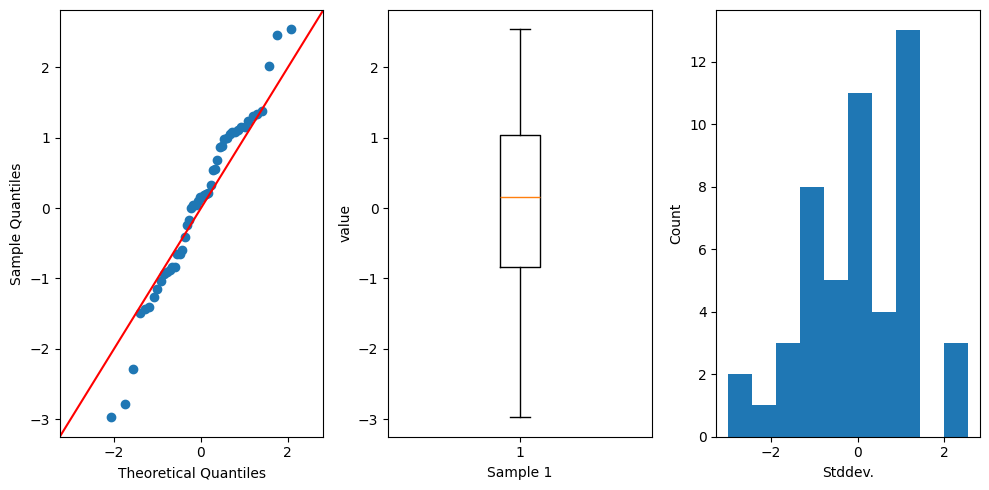

In [4]:
# np.random.randn(20)
x = np.random.normal(loc=0.0, scale=1.0, size=50)  # creating 50 random numbers from a normal distribution

fig, ax = plt.subplots(ncols=3, figsize=(10, 5))

sm.qqplot(x, line='45', ax=ax[0])
ax[1].boxplot(x)
ax[2].hist(x)
# add the axis labels
ax[1].set_xlabel('Sample 1')
ax[1].set_ylabel('value')
ax[2].set_xlabel('Stddev.')
ax[2].set_ylabel('Count')
# run tight_layout() as it typically helps to improve the proportions of the graphics
plt.tight_layout()
plt.show()

In [5]:
# support with Shapiro-Wilk test
# H0: The values are normal distributed (ATTENTION!)
stats.shapiro(x)

ShapiroResult(statistic=np.float64(0.9748959679952209), pvalue=np.float64(0.36162661957035724))

### Reporting the test results
Test results should be reported including the 
- test statistic
- p-value (probability of the test statistic)
- (sample size ***n***)

Example: A student t-test to test if the sample mean of NDVI values of 2012 is different to 0.5 yields a p-value of 0.004 and a test statistic of -3.820 with a sample size n = 5.

We can write the result as follows:

<font color=blue> The NDVI values of 2012 differ statistically significant from 0.5 (t$_{~-3.820},p<0.005,n=5$)</font>

You write the probability of the test statistic as rounded numbers, 0.1, 0.05, 0.01, 0.005, etc.

## Tasks

<font color=grey>

1. Question: Are there differences in NDVI between different elevations? You expand on the basic example by defining elevation intervals (optimally just two for a start) and display differences in NDVI for the two classes.

2. Question: Are there differences in decrease of NDVI in one type of land use (MCD12Q1) but for different elevation classes? You combine e.g. land use and elevation classes to study this question for the dry summers. You should define your question and are free to also use, e.g., exposition (aspect). The ones that are more advanced can also combine three conditions. It is also possible to investigate whether the signal is always present (dry and moist summers) or more pronounced in dry summers.

3. You can choose between Jura and Fribourg for your analysis. Those of you who are fast, can do it for both.
</font>

**4. Think of the test you want to perform to substantiate your analysis/discussion.**

<font color=grey>
<br>

**Mandatory processing steps:**

- Set NDVI values outside meaningful range (x < 0 and x > 1) to NA
    - for each of the NDVI files individually
- Create boxplots showcasing the different years against each other (all pixels for the individual files)
    - use the `list()` function to provide the data to the boxplot function as shown in the example above
- Select values by elevation range (you can select other elevation ranges than those indicated below!)
    - Get indices using the DEM for the elevation ranges:
        - 100 to 1000 m
        - 1000 to 3000 m
    - Select values from the NDVI files using these indices
        - for each of the files individually
    - Create boxplots showcasing the difference between elevation classes (same year)
    - Create boxplots showcasing the difference between years (same elevation classes)
</font>
***
- 
    - Formulate and justify/describe your main research question (the one that you will apply a test on)in a few sentences.
    - Formulate hypothesis to test
        - Select your test(s) and explain why you chose them. Use Fig.3 and Fig.4 to justify your choice.
        - What are your H0/H1 (write them down)?
        - Report the test result
    - Discuss the results with respect to your research question
    

## Overview on tests in `Python`

- Normality test
- Variance test (F-test for equal variances)

- 1-sample z-test
- 1-sample t-test
- 2-sample t-test (equal variances)
- 2-sample Welch's t-test (unequal variances)
- 2-sample paired sample t-test
- 1-sample Wilcoxon median test
- 2-sample Mann-Whitney U-test
- 2-sample Wilcoxon Paired-Sample test
- 2-sample Pearson rank correlation
- (more than 2 sample tests - not discussed)

In the following we list for each test (i) the packages you need to import, (ii) create sample data, and (iii) provide the code to do the test.

In [6]:
# ---- Normality test ----
from scipy import stats  # package only needed to create the sample data
import numpy as np       # package needed to perform the test

# Sample data: create 20 random numbers from a normal distribution
x = np.random.normal(loc=10, scale=1.5, size=200)

# carry out the test
stats.shapiro(x)

ShapiroResult(statistic=np.float64(0.9927357229364719), pvalue=np.float64(0.4266142190600055))

In [7]:
# ---- Variance test (F-test) ----
import numpy as np             # package needed to create the sample data and some test parameters
import scipy.stats as stats    # package needed to calculate some of the test statistics

# Create the data for two groups
group1 = np.random.normal(loc=10, scale=1.5, size=20)
group2 = np.random.normal(loc=25, scale=1.7, size=30)

# Calculate the sample variances
variance1 = np.var(group1, ddof=1)
variance2 = np.var(group2, ddof=1)

# Calculate the F-statistic
f_value = variance1 / variance2

# Calculate the degrees of freedom
df1 = len(group1) - 1
df2 = len(group2) - 1

# Calculate the p-value
p_value = stats.f.cdf(f_value, df1, df2)

# Print the results
print('Degree of freedom 1:',df1)
print('Degree of freedom 2:',df2)
print("F-statistic:", f_value)
print("p-value:", p_value)

Degree of freedom 1: 19
Degree of freedom 2: 29
F-statistic: 0.6287503730419727
p-value: 0.1470733421121181


In [8]:
# ----- 1 sample z test ----- #
# tests the mean of a distribution if the variance of the population is known

from statsmodels.stats.weightstats import ztest  # package needed to perform the test

# Sample
x = [88,89,94,94,96,97,97,97,99,99,105,109,102,109,110,112,112,113,114,130]

# Here we test whether the mean of the sample x is significantly different from our expected mean of 100
ztest(x, value=100)

# The first value is the test statistics, the second is  the p-value

(np.float64(1.4354968929081129), np.float64(0.15114555310091565))

In [9]:
# ----- 1-sample t-test  ----- 
import scipy.stats as stats  # package needed to perform the test
import numpy as np           # package needed to creat the sample data

x = np.random.normal(loc=10, scale=1.5, size=20)

stats.ttest_1samp(a=x, popmean=5000)

TtestResult(statistic=np.float64(-13217.108737408584), pvalue=np.float64(1.268871009216634e-67), df=np.int64(19))

In [10]:
# -----  2-sample t-test (equal variances) -----
# tests the means of two samples against each other
import scipy.stats as stats
import numpy as np           # package needed to creat the sample data

x = np.random.normal(loc=10, scale=1.5, size=50)
y = np.random.normal(loc=10, scale=1.5, size=50)

# Perform the two sample t-test with equal variances
stats.ttest_ind(a=x, b=y, equal_var=True)

TtestResult(statistic=np.float64(-0.7596196625043768), pvalue=np.float64(0.4493053957631974), df=np.float64(98.0))

In [11]:
# ----- 2-sample Welch's t-test (unequal variances) -----
import scipy.stats as stats
import numpy as np           # package needed to creat the sample data

x = np.random.normal(loc=10, scale=1.5, size=50)
y = np.random.normal(loc=10, scale=1.5, size=50)

# Perform the two sample Welch's t-test 
stats.ttest_ind(a=x, b=y, equal_var=False)

TtestResult(statistic=np.float64(0.0941363989508955), pvalue=np.float64(0.9251977895211883), df=np.float64(95.61750998699306))

In [12]:
# ----- 2-sample paired sample t-test ----- 
# the paired test requires a sample from the same individuals/objects with the same sample size n

import scipy.stats as stats

# Data before and after treatment
before_treatment = [10, 12, 14, 16, 18, 2]
after_treatment = [9, 13, 14, 17, 19, 7]

# Example (same n !)
stats.ttest_rel(before_treatment, after_treatment)

TtestResult(statistic=np.float64(-1.4000000000000001), pvalue=np.float64(0.2204038799293444), df=np.int64(5))

In [13]:
# ----- 1-sample Wilcoxon median test -----
# tests if the distribution median is equal to a given value (like 1 sample t-test but with median and for non-normal)

import numpy as np
import scipy.stats as stats

# Example
x = np.random.normal(loc=12, scale=2, size=90)
y = np.random.normal(loc=4, scale=2, size=10)
xy = np.append(x, y)  # append both arrays into one array

print(stats.shapiro(xy))  # test whether the data are normal, they need to be non-normal for Wilcoxon!
stats.wilcoxon(xy)


ShapiroResult(statistic=np.float64(0.9320104736512131), pvalue=np.float64(6.483729837294464e-05))


WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(3.896559845095909e-18))

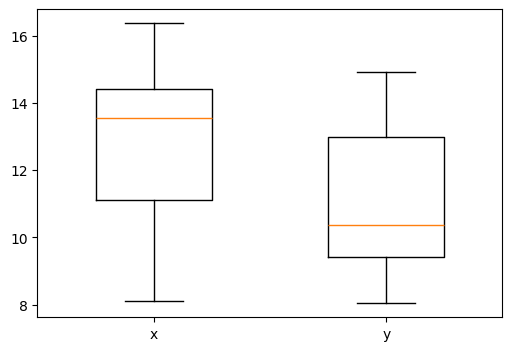

ShapiroResult(statistic=np.float64(0.94279872307875), pvalue=np.float64(0.10821009512710783))
ShapiroResult(statistic=np.float64(0.8818792553370121), pvalue=np.float64(0.0031145917380941213))


WilcoxonResult(statistic=np.float64(75.0), pvalue=np.float64(0.0007296018302440643))

In [14]:
# ----- 2-sample Mann-Whitney U-test -----
# tests if the two distributions are different (towards higher or lower values) 
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt


# Example
x1 = np.random.normal(loc=14, scale=1, size=20)
y1 = np.random.normal(loc=10, scale=1, size=10)
x2 = np.random.normal(loc=14, scale=1, size=10)
y2 = np.random.normal(loc=10, scale=1, size=20)

x = np.append(x1, y1)  # append both arrays into one array
y = np.append(x2, y2)  # append both arrays into one array

# create a boxplot to visualize the data
fig, ax = plt.subplots(1, 1, figsize=(6,4))
bplot = ax.boxplot([x, y], widths=0.5, tick_labels =['x','y'])
plt.show()

# quick check if normally distributed
print(stats.shapiro(x))
print(stats.shapiro(y))

stats.wilcoxon(x, y)

# wilcox.test(x, y)

In [15]:
# ----- 2-sample Wilcoxon Paired-Sample test  ----- 
# the same but for paired data
print(stats.wilcoxon(x, y))


# ----- 2-sample Pearson rank correlation -----
stats.pearsonr(x, y) 

WilcoxonResult(statistic=np.float64(75.0), pvalue=np.float64(0.0007296018302440643))


PearsonRResult(statistic=np.float64(0.3793951076738368), pvalue=np.float64(0.0386624163573891))